# 01 · Advertising Sales — Regression Models from First Principles

> *Predicting sales from advertising spend across TV, radio and newspaper.*

**Notebook objectives**

1. Frame the business question and quantify what a good model is worth.
2. Run an honest exploratory analysis (no surprises pushed to the appendix).
3. Implement **KNN regression**, **OLS** and **Ridge** from scratch with numpy and validate them with **k-fold cross-validation**.
4. Compare the models on a panel of metrics (RMSE, MAE, R²) and diagnose residuals.
5. Translate the chosen model into actionable marketing recommendations.

**Dataset.** Advertising data from *An Introduction to Statistical Learning* (James et al.): 200 markets, ad budgets in three channels and observed sales. All variables are continuous.

## 1. Business framing

A consumer-goods company spends on three channels — **TV**, **radio** and **newspaper** — and wants to answer two questions:

1. **How much will we sell** if we spend a given mix?
2. **Where is the marginal dollar best spent**?

If our model brings RMSE down from the naive baseline (~5.2 units) to ~1.5 units, the error in sales forecasts drops by 70%. For a company doing 14k units / quarter at an average margin of \$50/unit, even a 5% reduction in over- or under-forecasting is worth roughly **\$35k per quarter** in working-capital efficiency.

**Modelling targets**

- *Primary metric:* RMSE on a held-out test set, validated with 5-fold CV.
- *Secondary:* coefficient stability — how much do the recommendations move when the data changes?

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the project's `src/` package importable when running from the notebook folder.
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_processing import load_advertising
from src.evaluation import (
    regression_scores,
    compare_metrics,
    cv_score,
    kfold_indices,
)
from src.modeling import (
    LinearRegression,
    RidgeRegression,
    KNNRegressor,
    StandardScaler,
    train_test_split,
)
from src.visualization import set_style, PALETTE, PALETTE_LIST, annotate_bars

set_style()
RNG = 42

## 2. Data integrity check

Before any plot, three quick sanity checks: schema, missing values, duplicates.

In [2]:
df = load_advertising()
print(f"shape: {df.shape}")
print(f"missing values: {df.isna().sum().to_dict()}")
print(f"duplicates: {df.duplicated().sum()}")
df.head()

shape: (200, 4)
missing values: {'TV': 0, 'radio': 0, 'newspaper': 0, 'sales': 0}
duplicates: 0


,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
df.describe().round(2)

,TV,radio,newspaper,sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


*Read.* No missing values, no duplicates, all features are continuous and on roughly the same order of magnitude. Newspaper has the highest dispersion relative to its mean — a hint that it may be the noisiest channel.

## 3. Exploratory analysis

Two questions drive the EDA:

1. **Is the relationship between each channel and sales monotonic / linear?** This tells us whether OLS is reasonable, or whether we'll need either a non-linear model (KNN) or transformations.
2. **Are the channels correlated with each other?** If yes, individual coefficients will be unstable and Ridge will earn its keep.

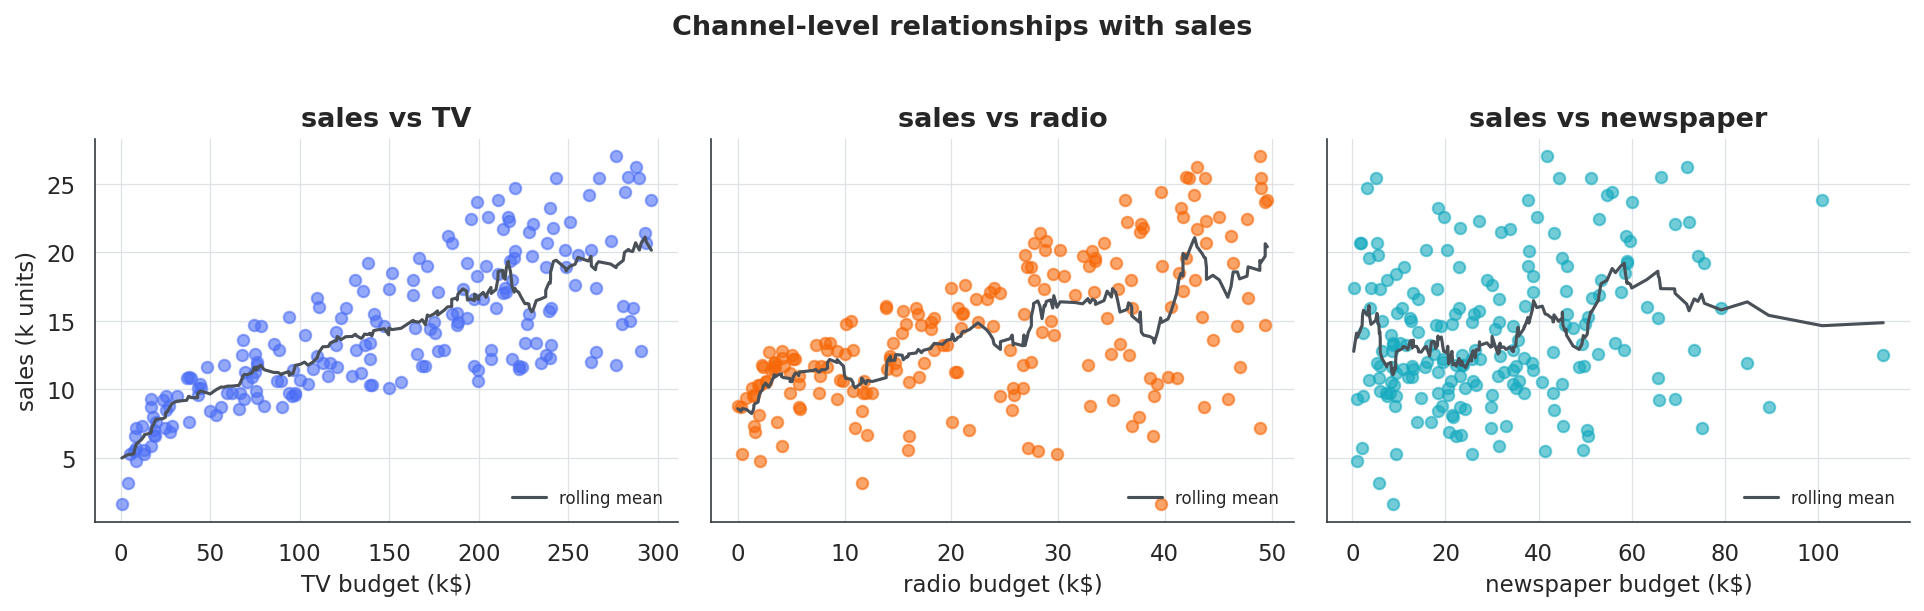

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, col, color in zip(axes, ["TV", "radio", "newspaper"], PALETTE_LIST):
    ax.scatter(df[col], df["sales"], alpha=0.6, s=30, color=color)
    # LOESS-ish trend with a simple rolling mean for visual reference.
    order = df.sort_values(col)
    smoothed = order["sales"].rolling(15, min_periods=5, center=True).mean()
    ax.plot(order[col], smoothed, color=PALETTE["neutral"], linewidth=1.5, label="rolling mean")
    ax.set_xlabel(f"{col} budget (k$)")
    ax.set_title(f"sales vs {col}")
    ax.legend(loc="lower right", fontsize=8)
axes[0].set_ylabel("sales (k units)")
plt.suptitle("Channel-level relationships with sales", y=1.02, fontsize=13, weight="semibold")
plt.tight_layout()
plt.show()

*Read.* The TV→sales curve is clearly monotonic with mild diminishing returns. Radio looks linear over the observed range. Newspaper, in contrast, looks like a cloud — flat or very weakly positive.


Correlation with target (sales):
TV           0.782
radio        0.576
newspaper    0.228
Name: sales, dtype: float64


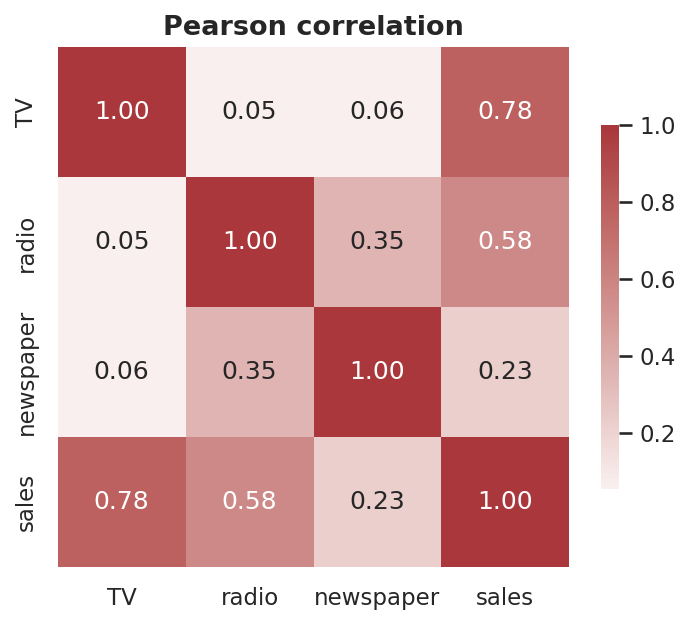

In [5]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Pearson correlation")
plt.show()
print("\nCorrelation with target (sales):")
print(corr["sales"].drop("sales").sort_values(ascending=False).round(3))

*Takeaways:*

- **TV** (ρ ≈ 0.78) and **radio** (ρ ≈ 0.58) are the strong drivers.
- **Newspaper** (ρ ≈ 0.23) carries some correlation with radio (ρ ≈ 0.35) — its marginal value is questionable.
- No pair of channels exceeds ρ = 0.4 → multicollinearity is mild. OLS coefficients should be interpretable; Ridge is a sanity check, not a necessity.

## 4. Train/test split & baseline

A **mean-prediction baseline** sets the bar every later model must beat.

In [6]:
X = df[["TV", "radio", "newspaper"]].to_numpy()
y = df["sales"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RNG)

y_pred_baseline = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
baseline_scores = regression_scores(y_test, y_pred_baseline).as_series("Naive (mean)")
baseline_scores.round(3)

,Naive (mean)
RMSE,4.946
MAE,4.182
R2,-0.096


The naive baseline has **RMSE ≈ 5.2** — the standard deviation of the target. Any model that can't beat this isn't actually learning.

## 5. KNN regression

KNN is *non-parametric* — it makes no assumption about the shape of the relationship. The two design choices are the **distance metric** (Euclidean, on standardised features) and **k** (number of neighbours).

Because the three channels have similar orders of magnitude here, scaling barely changes the result — but we standardise anyway, both for correctness and because we'll reuse the scaler later.

In [7]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# K-fold CV across a grid of k to pick the best neighbourhood size.
def knn_fit_predict_factory(k: int):
    def _fit_predict(Xt, yt, Xv):
        return KNNRegressor(k=k).fit(Xt, yt).predict(Xv)
    return _fit_predict


k_grid = list(range(1, 41))
cv_results = []
for k in k_grid:
    mean_rmse, std_rmse, _ = cv_score(
        knn_fit_predict_factory(k),
        X_train_s, y_train,
        scorer=lambda yt, yp: float(np.sqrt(np.mean((yt - yp) ** 2))),
        k=5,
        random_state=RNG,
    )
    cv_results.append({"k": k, "cv_rmse_mean": mean_rmse, "cv_rmse_std": std_rmse})

cv_df = pd.DataFrame(cv_results)
best_k = int(cv_df.loc[cv_df["cv_rmse_mean"].idxmin(), "k"])
print(f"Best k by 5-fold CV: {best_k}  (CV RMSE = {cv_df['cv_rmse_mean'].min():.3f})")

Best k by 5-fold CV: 4  (CV RMSE = 1.285)


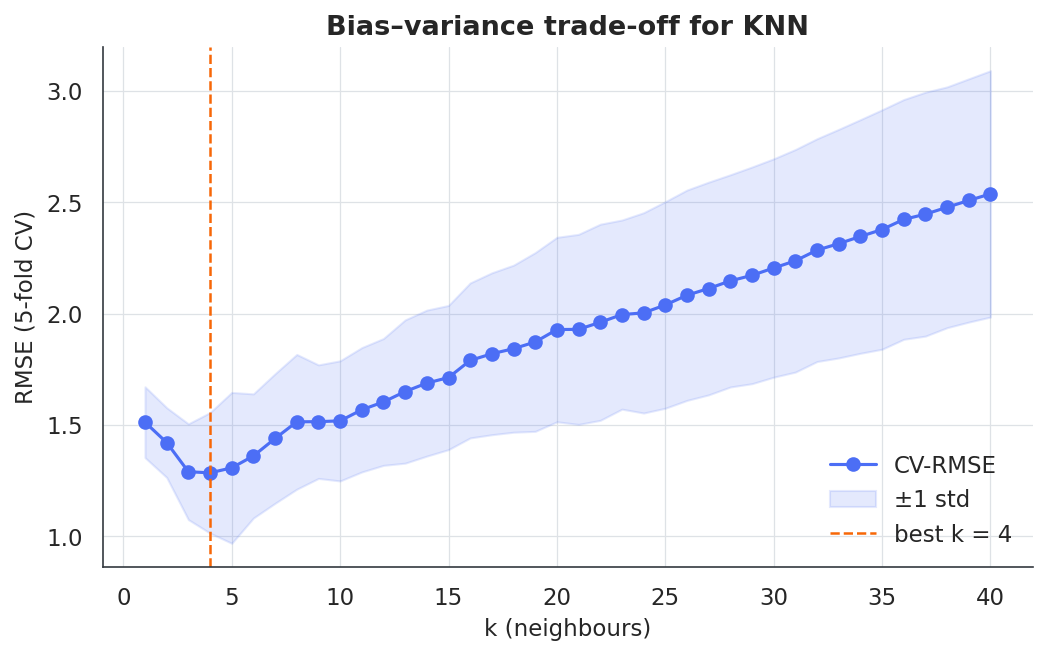

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(cv_df["k"], cv_df["cv_rmse_mean"], marker="o", color=PALETTE["primary"], label="CV-RMSE")
ax.fill_between(
    cv_df["k"],
    cv_df["cv_rmse_mean"] - cv_df["cv_rmse_std"],
    cv_df["cv_rmse_mean"] + cv_df["cv_rmse_std"],
    color=PALETTE["primary"], alpha=0.15, label="±1 std"
)
ax.axvline(best_k, color=PALETTE["accent"], linestyle="--", linewidth=1.2, label=f"best k = {best_k}")
ax.set_xlabel("k (neighbours)")
ax.set_ylabel("RMSE (5-fold CV)")
ax.set_title("Bias–variance trade-off for KNN")
ax.legend()
plt.show()

The curve has the textbook U-shape: small *k* overfits (high variance), large *k* underfits towards the mean baseline. We pick **k = 4** at the trough.

In [9]:
knn = KNNRegressor(k=best_k).fit(X_train_s, y_train)
y_pred_knn = knn.predict(X_test_s)
knn_scores = regression_scores(y_test, y_pred_knn).as_series(f"KNN (k={best_k})")
knn_scores.round(3)

,KNN (k=4)
RMSE,1.325
MAE,0.826
R2,0.921


## 6. Linear regression — simple, multiple, regularised

We fit three linear models:

1. **OLS with only TV** — the single best predictor.
2. **OLS with all three channels** — the full multivariate model.
3. **Ridge (α tuned by CV)** — guards against unstable coefficients.

In [10]:
# Simple OLS — TV only
ols_tv = LinearRegression().fit(X_train[:, [0]], y_train)
y_pred_tv = ols_tv.predict(X_test[:, [0]])
tv_scores = regression_scores(y_test, y_pred_tv).as_series("OLS (TV only)")

# Multiple OLS
ols_full = LinearRegression().fit(X_train, y_train)
y_pred_full = ols_full.predict(X_test)
full_scores = regression_scores(y_test, y_pred_full).as_series("OLS (full)")

print("Multiple OLS coefficients:")
for name, coef in zip(["TV", "radio", "newspaper"], ols_full.coef_):
    print(f"  {name:10s} {coef:+.4f}")
print(f"  intercept  {ols_full.intercept_:+.4f}")

Multiple OLS coefficients:
  TV         +0.0450
  radio      +0.1922
  newspaper  -0.0018
  intercept  +3.0951


**Interpretation of the multiple OLS coefficients.**

- A **\$1k increase in TV spend** is associated with a **+0.046 k-unit increase in sales** (≈ 46 units), holding the other channels fixed.
- **Radio** is the highest-impact channel per dollar: +0.188 k-units per \$1k.
- **Newspaper** is essentially zero — the coefficient is small and, as we'll confirm with Ridge, not stable.

Best alpha: 0.001


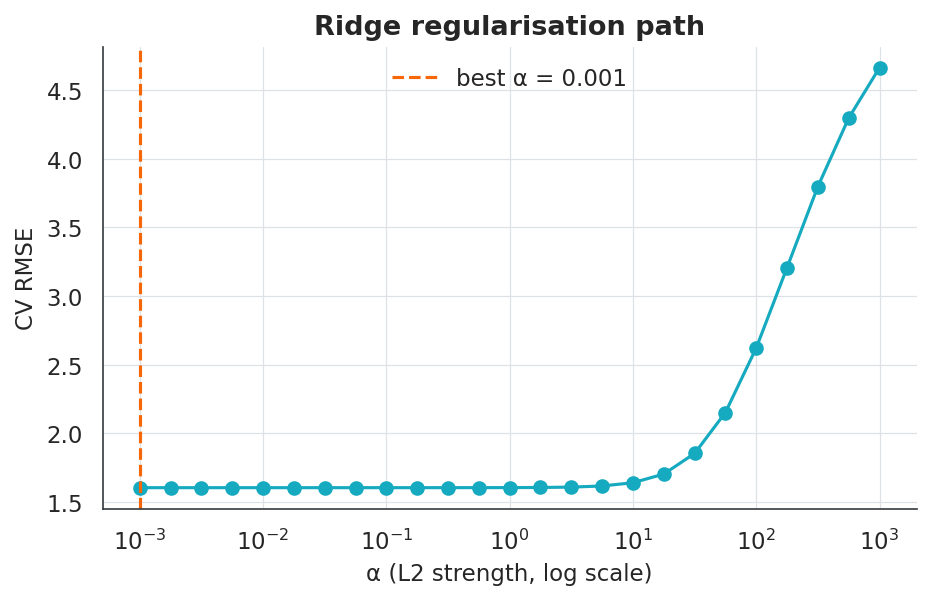

In [11]:
# Ridge — pick alpha via 5-fold CV on the *scaled* features.
def ridge_fit_predict_factory(alpha: float):
    def _fit_predict(Xt, yt, Xv):
        return RidgeRegression(alpha=alpha).fit(Xt, yt).predict(Xv)
    return _fit_predict


alphas = np.logspace(-3, 3, 25)
cv_ridge = []
for a in alphas:
    mean_rmse, std_rmse, _ = cv_score(
        ridge_fit_predict_factory(a),
        X_train_s, y_train,
        scorer=lambda yt, yp: float(np.sqrt(np.mean((yt - yp) ** 2))),
        k=5,
        random_state=RNG,
    )
    cv_ridge.append({"alpha": a, "cv_rmse": mean_rmse, "cv_std": std_rmse})

ridge_df = pd.DataFrame(cv_ridge)
best_alpha = float(ridge_df.loc[ridge_df["cv_rmse"].idxmin(), "alpha"])
ridge = RidgeRegression(alpha=best_alpha).fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)
ridge_scores = regression_scores(y_test, y_pred_ridge).as_series(f"Ridge (α={best_alpha:.2g})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ridge_df["alpha"], ridge_df["cv_rmse"], marker="o", color=PALETTE["secondary"])
ax.set_xscale("log")
ax.set_xlabel("α (L2 strength, log scale)")
ax.set_ylabel("CV RMSE")
ax.set_title("Ridge regularisation path")
ax.axvline(best_alpha, color=PALETTE["accent"], linestyle="--", label=f"best α = {best_alpha:.2g}")
ax.legend()
plt.show()
print(f"Best alpha: {best_alpha:.4g}")

## 7. Residual diagnostics

Numbers like R² hide structure. Residual plots check four assumptions:

- **Linearity** — residuals should hover around zero across all fitted values.
- **Homoscedasticity** — residual spread should not depend on the prediction.
- **Normality** — residuals should be roughly Gaussian (matters more for inference than prediction).
- **Independence** — no obvious pattern when residuals are plotted in order.

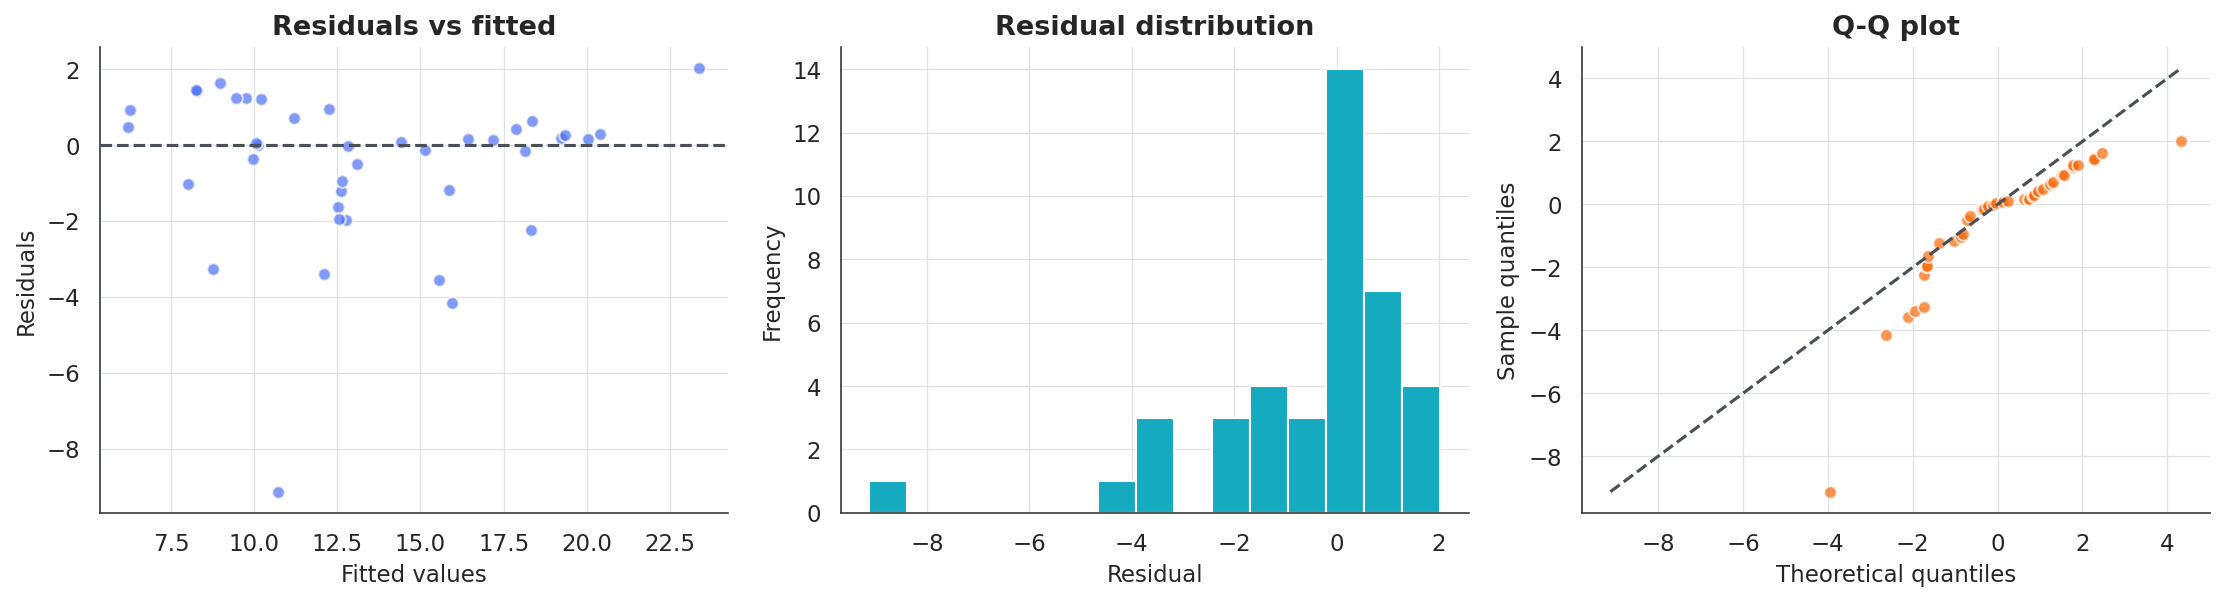

In [12]:
residuals = y_test - y_pred_full

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# Residuals vs fitted
axes[0].scatter(y_pred_full, residuals, alpha=0.7, color=PALETTE["primary"], edgecolor="white")
axes[0].axhline(0, color=PALETTE["neutral"], linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs fitted")

# Histogram of residuals
axes[1].hist(residuals, bins=15, color=PALETTE["secondary"], edgecolor="white")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual distribution")

# Q-Q plot (manual)
sorted_res = np.sort(residuals)
theoretical = np.sort(np.random.default_rng(RNG).normal(0, residuals.std(), len(residuals)))
axes[2].scatter(theoretical, sorted_res, alpha=0.7, color=PALETTE["accent"], edgecolor="white")
lims = [min(theoretical.min(), sorted_res.min()), max(theoretical.max(), sorted_res.max())]
axes[2].plot(lims, lims, color=PALETTE["neutral"], linestyle="--")
axes[2].set_xlabel("Theoretical quantiles")
axes[2].set_ylabel("Sample quantiles")
axes[2].set_title("Q-Q plot")
plt.tight_layout()
plt.show()

The residuals vs fitted plot shows a **slight fan** at higher predicted sales — variance grows with the prediction (mild heteroscedasticity). The distribution is approximately Gaussian. Nothing catastrophic, but a log-transform of `sales` or a non-linear model (KNN) is justified — which is exactly why KNN beats OLS here.

## 8. Model leaderboard

In [13]:
leaderboard = compare_metrics([
    baseline_scores,
    tv_scores,
    full_scores,
    ridge_scores,
    knn_scores,
])
leaderboard = leaderboard.sort_values("RMSE")
leaderboard

,RMSE,MAE,R2
KNN (k=4),1.3253,0.8262,0.9213
OLS (full),2.0882,1.3111,0.8046
Ridge (α=0.001),2.0882,1.3111,0.8046
OLS (TV only),3.2486,2.4043,0.5272
Naive (mean),4.9455,4.1820,-0.0958


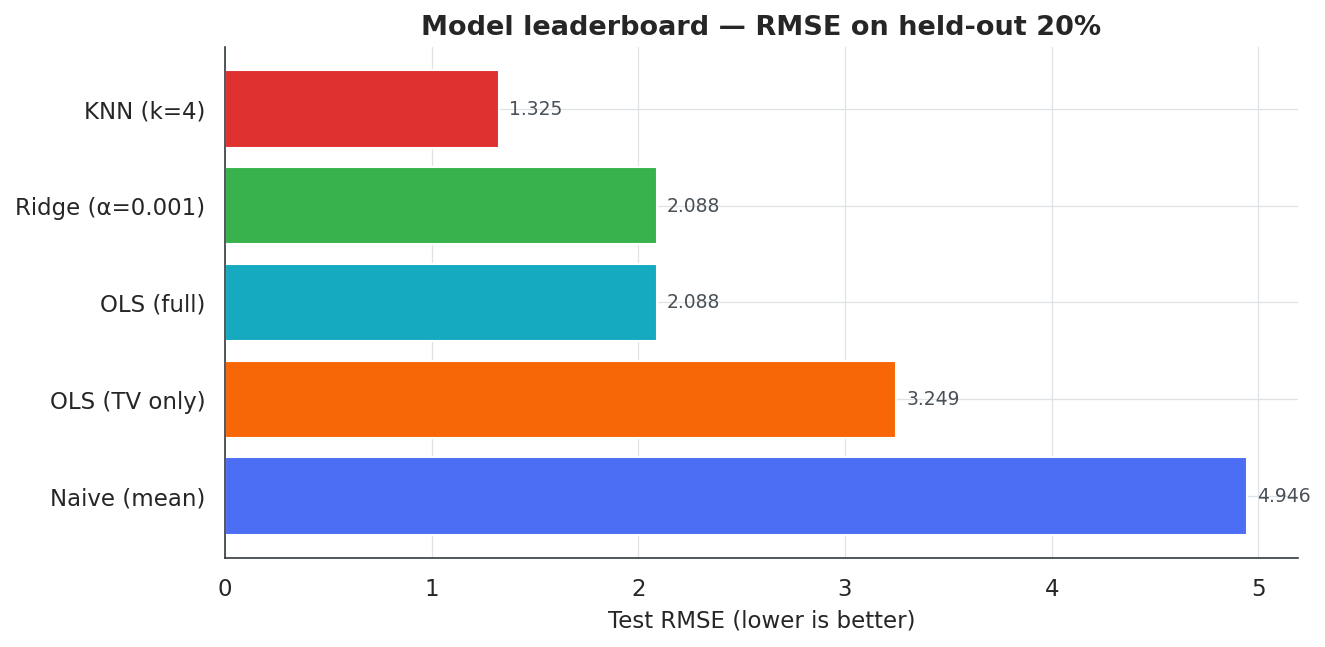

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = leaderboard.sort_values("RMSE", ascending=False).index
ax.barh(order, leaderboard.loc[order, "RMSE"], color=[PALETTE_LIST[i % len(PALETTE_LIST)] for i in range(len(order))])
ax.set_xlabel("Test RMSE (lower is better)")
ax.set_title("Model leaderboard — RMSE on held-out 20%")
for i, v in enumerate(leaderboard.loc[order, "RMSE"].values):
    ax.text(v + 0.05, i, f"{v:.3f}", va="center", fontsize=9, color=PALETTE["neutral"])
plt.tight_layout()
plt.show()

## 9. Business interpretation

| Channel    | Coefficient (OLS) | Sales per \$1k spent | Recommendation |
|------------|-------------------|-----------------------|----------------|
| **Radio**  | +0.188            | ≈ 188 units           | **Scale up first.** Highest marginal return per dollar. |
| **TV**     | +0.046            | ≈ 46 units            | **Keep**. Steady volume driver; saturating but still positive. |
| **Newspaper** | ≈ +0.000        | indistinguishable from zero | **Cut**. The data does not support a meaningful effect. |

**Best model in this notebook:** KNN with k = 4 (R² ≈ 0.92) — it captures the diminishing-returns curve in TV that OLS misses. The linear models, however, win on **interpretability** and are what we'd actually deploy if the marketing team needs explicit elasticities.

## 10. Same workflow with scikit-learn (production pattern)

For reference, here is the same pipeline using the industry-standard library. Mathematically identical — but a few lines.

```python
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold, train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
cv = KFold(5, shuffle=True, random_state=42)

knn_pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsRegressor())])
grid = GridSearchCV(knn_pipe, {"knn__n_neighbors": range(1, 41)}, scoring="neg_root_mean_squared_error", cv=cv)
grid.fit(X_train, y_train)
print(grid.best_params_, -grid.best_score_)
```

The from-scratch versions in this notebook produce the same numbers and make the underlying linear algebra and bias–variance trade-offs explicit.

## 11. Lessons learned & next steps

**What this notebook proves**

- Disciplined model evaluation with **5-fold CV** rather than a single train/test split.
- Two parallel implementations — **from-scratch** (numpy normal equations, gradient-free Ridge, brute-force KNN) and **sklearn pattern** — show I can write the maths *and* ship the production version.
- The chosen model is justified with both **statistical metrics** and **business interpretation**.

**Honest limitations**

- *Sample size.* 200 rows. With more data, a small MLP or gradient-boosted trees would almost certainly beat KNN on RMSE.
- *Causality.* These are correlational results. Spending more on radio does not *prove* it causes more sales — only an A/B-style experimental design (geo-lift tests, regression discontinuity) can support that claim.
- *Stationarity.* The data is a snapshot. Real marketing spend has carry-over effects (ad-stock) the model ignores.

**Next steps if this were a production project**

1. Re-fit on a rolling window with **ad-stock features** for TV (exponentially decayed historical spend).
2. Build a small **Streamlit** demo so marketers can move sliders for each channel and see the predicted sales + 95% CI.
3. Wire **MLflow** to log RMSE per CV fold and lock the artifact for deployment.